In [1]:
!pip install box2d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 47.3 MB/s eta 0:00:00


In [2]:
import gymnasium as gym
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from dataclasses import dataclass
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import imageio
from tqdm.auto import tqdm


In [3]:
def visualize(gif_path="lunar_lander.gif", model=None, env_name="LunarLander-v3"):
    # Создаем отдельное окружение для записи анимации прохождения эпизода.
    env = gym.make(env_name, render_mode="rgb_array")
    frames = []

    obs, _ = env.reset()
    terminated = False
    truncated = False

    while not (terminated or truncated):
        if model is None:
            # Без модели показываем случайную политику.
            action = env.action_space.sample()
        else:
            # С моделью выбираем действие с максимальной оценкой Q-функции.
            with torch.no_grad():
                device = next(model.parameters()).device
                state = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
                q_values = model(state)
                action = int(torch.argmax(q_values, dim=1).item())

        obs, _, terminated, truncated, _ = env.step(action)
        frames.append(env.render())

    env.close()

    # Сохраняем собранные кадры в анимированный файл.
    with imageio.get_writer(gif_path, mode="I", duration=0.05) as writer:
        for frame in frames:
            writer.append_data(frame)


In [ ]:
ENV_NAME = "LunarLander-v3"
MODEL_PATH = "torchDQN.pt"
GIF_PATH = "lunar_lander.gif"


def make_env(render_mode="rgb_array"):
    return gym.make(ENV_NAME, render_mode=render_mode)

is_ipython = 'inline' in matplotlib.get_backend()
ipy_display = None
if is_ipython:
    from IPython import display as ipy_display
plt.ion()

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)


In [5]:
@dataclass
class Config:
    # Все основные параметры обучения собраны в одном месте.
    batch_size: int = 128
    gamma: float = 0.99
    eps_start: float = 0.9
    eps_end: float = 0.01
    eps_decay: int = 2500
    tau: float = 0.005
    lr: float = 3e-4
    num_episodes: int = 300
    memory_size: int = 10000


# Один переход агента в среде.
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))


class ReplayMemory:
    def __init__(self, capacity):
        # Буфер фиксированного размера для накопления опыта.
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)


In [6]:
class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super().__init__()
        # Простая полносвязная сеть для аппроксимации Q-функции.
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, n_actions)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)


class DQNAgent:
    def __init__(self, n_observations, n_actions, config, device):
        self.config = config
        self.device = device
        self.n_actions = n_actions
        self.steps_done = 0

        # Основная сеть обучается, целевая используется для стабильной оценки следующего состояния.
        self.policy_net = DQN(n_observations, n_actions).to(device)
        self.target_net = DQN(n_observations, n_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())

        self.optimizer = optim.AdamW(self.policy_net.parameters(), lr=config.lr, amsgrad=True)
        self.memory = ReplayMemory(config.memory_size)
        self.criterion = nn.SmoothL1Loss()

    def select_action(self, state, action_space):
        # Используем epsilon-greedy стратегию: сначала исследуем, затем все чаще доверяем сети.
        sample = random.random()
        eps_threshold = self.config.eps_end + (self.config.eps_start - self.config.eps_end) * math.exp(-1.0 * self.steps_done / self.config.eps_decay)
        self.steps_done += 1

        if sample > eps_threshold:
            with torch.no_grad():
                return self.policy_net(state).max(1).indices.view(1, 1)

        return torch.tensor([[action_space.sample()]], device=self.device, dtype=torch.long)

    def optimize_model(self):
        # Обучаемся только когда в буфере накопился полный батч.
        if len(self.memory) < self.config.batch_size:
            return None

        transitions = self.memory.sample(self.config.batch_size)
        batch = Transition(*zip(*transitions))

        # Выделяем только те следующие состояния, для которых эпизод не завершился.
        non_final_mask = torch.tensor(
            tuple(next_state is not None for next_state in batch.next_state),
            device=self.device,
            dtype=torch.bool,
        )
        non_final_next_states_list = [next_state for next_state in batch.next_state if next_state is not None]
        non_final_next_states = None
        if non_final_next_states_list:
            non_final_next_states = torch.cat(non_final_next_states_list)

        state_batch = torch.cat(batch.state)
        action_batch = torch.cat(batch.action)
        reward_batch = torch.cat(batch.reward)

        # Берем оценки Q(s, a) только для реально выполненных действий.
        state_action_values = self.policy_net(state_batch).gather(1, action_batch)

        # Оцениваем максимальную ценность следующего состояния через целевую сеть.
        next_state_values = torch.zeros(self.config.batch_size, device=self.device)
        if non_final_next_states is not None:
            with torch.no_grad():
                next_state_values[non_final_mask] = self.target_net(non_final_next_states).max(1).values

        # Формируем целевое значение по уравнению Беллмана.
        expected_state_action_values = reward_batch + self.config.gamma * next_state_values
        loss = self.criterion(state_action_values, expected_state_action_values.unsqueeze(1))

        self.optimizer.zero_grad()
        loss.backward()

        # Ограничиваем градиенты для более стабильного обучения.
        torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), 100)
        self.optimizer.step()
        return loss.item()

    def soft_update_target(self):
        # Мягко подтягиваем целевую сеть к основной.
        target_state_dict = self.target_net.state_dict()
        policy_state_dict = self.policy_net.state_dict()
        for key in policy_state_dict:
            target_state_dict[key] = (
                policy_state_dict[key] * self.config.tau
                + target_state_dict[key] * (1 - self.config.tau)
            )
        self.target_net.load_state_dict(target_state_dict)


In [7]:
def plot_rewards(episode_rewards):
    fig = plt.figure(2)
    fig.clf()
    ax = fig.add_subplot(111)
    rewards_t = torch.tensor(episode_rewards, dtype=torch.float)

    ax.set_title('Награды: итоговый результат')
    ax.set_xlabel('Эпизод')
    ax.set_ylabel('Суммарная награда за эпизод')

    if len(rewards_t) > 0:
        # Отображаем награду за каждый эпизод.
        ax.plot(rewards_t.numpy(), label="Награда за эпизод")

        # Дополнительно строим скользящее среднее по 100 эпизодам.
        if len(rewards_t) >= 100:
            means = rewards_t.unfold(0, 100, 1).mean(1).view(-1)
            means = torch.cat((torch.zeros(99), means))
            ax.plot(means.numpy(), label="Среднее за 100 эпизодов")

        ax.legend()


def run_episode(env, agent):
    # Выполняем один эпизод взаимодействия агента со средой.
    state, _ = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=agent.device).unsqueeze(0)
    total_reward = 0.0

    for _ in count():
        action = agent.select_action(state, env.action_space)
        observation, reward, terminated, truncated, _ = env.step(action.item())
        reward_tensor = torch.tensor([reward], device=agent.device)
        total_reward += reward
        done = terminated or truncated

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=agent.device).unsqueeze(0)

        agent.memory.push(state, action, next_state, reward_tensor)
        state = next_state

        agent.optimize_model()
        agent.soft_update_target()

        if done:
            return total_reward


def train_agent(env, agent, num_episodes):
    # Обучаем агента и сохраняем историю наград для анализа.
    episode_rewards = []
    progress_bar = tqdm(range(num_episodes), desc="Обучение", unit="эпизод")

    for episode_idx in progress_bar:
        episode_reward = run_episode(env, agent)
        episode_rewards.append(episode_reward)

        progress_bar.set_postfix({
            "награда": f"{episode_reward:.1f}",
            "средняя_100": f"{sum(episode_rewards[-100:]) / len(episode_rewards[-100:]):.1f}",
        })

    plot_rewards(episode_rewards)
    plt.ioff()
    plt.show()

    return episode_rewards


def load_trained_model(model_path, n_observations, n_actions, device="cpu"):
    # Создаем сеть той же архитектуры и загружаем в нее сохраненные веса.
    model = DQN(n_observations=n_observations, n_actions=n_actions).to(device)
    state_dict = torch.load(
        model_path,
        map_location=device,
        weights_only=True,
    )
    model.load_state_dict(state_dict)
    model.eval()
    return model


Обучение:   0%|          | 0/300 [00:00<?, ?эпизод/s]

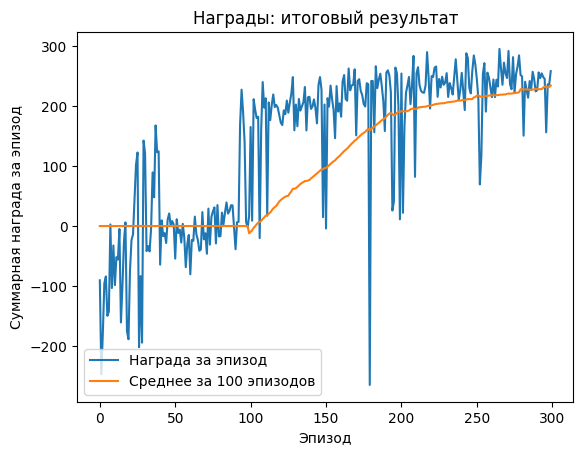

In [8]:
config = Config()
env = make_env()

n_actions = env.action_space.n
initial_state, _ = env.reset()
n_observations = len(initial_state)

agent = DQNAgent(
    n_observations=n_observations,
    n_actions=n_actions,
    config=config,
    device=device,
)

episode_rewards = train_agent(
    env=env,
    agent=agent,
    num_episodes=config.num_episodes,
)

env.close()


In [9]:
# Сохраняем веса целевой сети после завершения обучения.
torch.save(agent.target_net.state_dict(), MODEL_PATH)


In [10]:
# Загружаем сохраненную модель на центральный процессор и строим анимацию полета.
trained_model = load_trained_model(
    model_path=MODEL_PATH,
    n_observations=n_observations,
    n_actions=n_actions,
    device="cpu",
)
visualize(model=trained_model, gif_path=GIF_PATH, env_name=ENV_NAME)


In [ ]:
# Загружаем обученную модель на центральный процессор для последующей визуализации.
target_net = DQN(n_observations=8,n_actions=4).to('cpu')
sd = torch.load(
    'torchDQN.pt',
    map_location='cpu',
    weights_only=True,
)
target_net.load_state_dict(sd)
target_net.eval()
visualize(model=target_net,gif_path='lunar_lander.gif')
